MONTE CARLO NAV PROJECTION
Loading NAV data for scheme_code: 119551
Found 1150 NAV records
Last historical NAV: ₹149.32 on 2026-05-29
Annualized drift (μ): 0.2215 (22.15%)
Annualized volatility (σ): 0.1373 (13.73%)

Running 10000 simulations over 1260 trading days (5 years)...


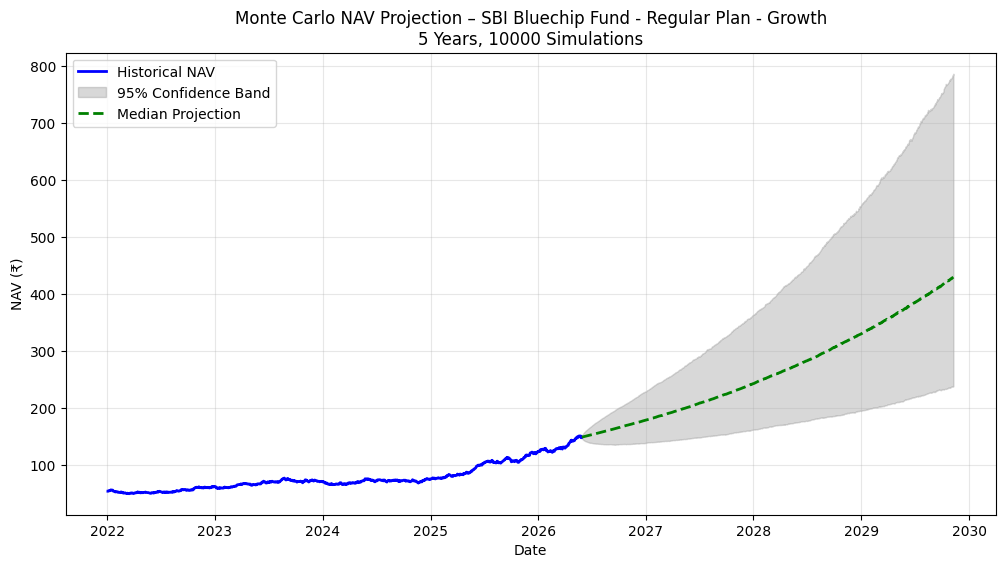

Chart saved to ..\data\processed\monte_carlo_projection.png

PROJECTION SUMMARY (Year-end values)
 Year Historical NAV (₹) Lower Band (₹) Median Projection (₹) Upper Band (₹)
 2022            62.9784              -                     -              -
 2023            71.8209              -                     -              -
 2024            74.9535              -                     -              -
 2025           124.0939              -                     -              -
 2026           149.3216              -                     -              -
 2027                  -         140.93                184.34         242.64
 2028                  -          156.0                227.43         331.23
 2029                  -         177.35                281.85         444.02
 2030                  -         203.23                348.59         594.87
 2031                  -         238.52                430.04         786.97

Summary table saved to ..\data\processed\monte_carlo_s

In [17]:
#!/usr/bin/env python3
# scripts/monte_carlo_nav.py
"""
Monte Carlo simulation for NAV projection (5 years) with uncertainty bands.
Uses Geometric Brownian Motion calibrated from historical NAV data.
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sqlite3
import os
from datetime import datetime, timedelta

# ==============================
# CONFIGURATION
# ==============================
DB_PATH = r"D:\bluestock_mf_capstone\data\db\bluestock_mf.db"
SCHEME_CODE = 119551          # SBI Bluechip Fund - Regular Plan (adjust as needed)
N_SIMULATIONS = 10000
YEARS = 5
TRADING_DAYS_PER_YEAR = 252
TOTAL_DAYS = YEARS * TRADING_DAYS_PER_YEAR
CONFIDENCE = 0.95             # 95% confidence bands

# ==============================
# DATA LOADING
# ==============================
def fetch_historical_nav(scheme_code):
    """Retrieve NAV time series from star schema."""
    if not os.path.exists(DB_PATH):
        raise FileNotFoundError(f"Database not found at {DB_PATH}")
    conn = sqlite3.connect(DB_PATH)
    query = """
        SELECT d.full_date AS date, n.nav_value AS nav
        FROM fact_nav n
        JOIN dim_date d ON n.date_id = d.date_id
        WHERE n.scheme_code = ?
        ORDER BY d.full_date ASC
    """
    df = pd.read_sql(query, conn, params=(scheme_code,), parse_dates=['date'])
    conn.close()
    if df.empty:
        raise ValueError(f"No NAV data found for scheme_code {scheme_code}")
    return df

def get_scheme_name(scheme_code):
    conn = sqlite3.connect(DB_PATH)
    cur = conn.cursor()
    cur.execute("SELECT scheme_name FROM dim_fund WHERE scheme_code = ?", (scheme_code,))
    row = cur.fetchone()
    conn.close()
    return row[0] if row else str(scheme_code)

# ==============================
# PARAMETER ESTIMATION
# ==============================
def estimate_parameters(df):
    """Calculate annualized drift (mu) and volatility (sigma) from log returns."""
    df['log_return'] = np.log(df['nav'] / df['nav'].shift(1))
    df_clean = df.dropna().copy()
    daily_mu = df_clean['log_return'].mean()
    daily_sigma = df_clean['log_return'].std()
    mu = daily_mu * TRADING_DAYS_PER_YEAR
    sigma = daily_sigma * np.sqrt(TRADING_DAYS_PER_YEAR)
    start_nav = df['nav'].iloc[-1]
    return mu, sigma, start_nav, df_clean

# ==============================
# SIMULATION ENGINE
# ==============================
def simulate_gbm(start_nav, mu, sigma, days):
    """Geometric Brownian Motion for one path."""
    dt = 1 / TRADING_DAYS_PER_YEAR
    daily_mu = mu * dt
    daily_sigma = sigma * np.sqrt(dt)
    shocks = np.random.normal(0, 1, days)
    log_returns = (daily_mu - 0.5 * daily_sigma**2) + daily_sigma * shocks
    log_price = np.log(start_nav) + np.cumsum(log_returns)
    price = np.exp(log_price)
    return np.insert(price, 0, start_nav)

def run_monte_carlo(start_nav, mu, sigma, days, n_sim):
    """Run multiple GBM simulations."""
    paths = np.zeros((n_sim, days + 1))
    for i in range(n_sim):
        paths[i] = simulate_gbm(start_nav, mu, sigma, days)
    return paths

def compute_percentiles(paths, confidence):
    """Calculate median, lower, upper bands."""
    lower_pct = (1 - confidence) / 2 * 100
    upper_pct = (1 + confidence) / 2 * 100
    median = np.percentile(paths, 50, axis=0)
    lower = np.percentile(paths, lower_pct, axis=0)
    upper = np.percentile(paths, upper_pct, axis=0)
    return median, lower, upper

# ==============================
# OUTPUT GENERATION
# ==============================
def plot_projection(historical_dates, historical_nav, future_days, median, lower, upper, scheme_name, last_date):
    plt.figure(figsize=(12, 6))
    plt.plot(historical_dates, historical_nav, label='Historical NAV', color='blue', linewidth=2)
    
    future_dates = [last_date + timedelta(days=i) for i in range(future_days + 1)]
    plt.fill_between(future_dates, lower, upper, color='gray', alpha=0.3,
                     label=f'{int(CONFIDENCE*100)}% Confidence Band')
    plt.plot(future_dates, median, label='Median Projection', color='green', linestyle='--', linewidth=2)
    
    plt.title(f'Monte Carlo NAV Projection – {scheme_name}\n{YEARS} Years, {N_SIMULATIONS} Simulations')
    plt.xlabel('Date')
    plt.ylabel('NAV (₹)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    out_dir = os.path.join('..', 'data', 'processed')
    os.makedirs(out_dir, exist_ok=True)
    out_img = os.path.join(out_dir, 'monte_carlo_projection.png')
    plt.savefig(out_img, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Chart saved to {out_img}")

def create_summary_table(historical_df, median, lower, upper, last_hist_date, years):
    """Create a clean wide-format table with historical and projected values."""
    # Historical yearly last NAV
    hist = historical_df.copy()
    hist['year'] = hist['date'].dt.year
    hist_last = hist.groupby('year')['nav'].last().reset_index()
    hist_last.columns = ['Year', 'Historical NAV (₹)']
    
    # Future projections at year-end indices
    future_rows = []
    for i in range(1, years + 1):
        idx = i * TRADING_DAYS_PER_YEAR
        if idx < len(median):
            year = last_hist_date.year + i
            future_rows.append({
                'Year': year,
                'Historical NAV (₹)': '-',
                'Lower Band (₹)': round(lower[idx], 2),
                'Median Projection (₹)': round(median[idx], 2),
                'Upper Band (₹)': round(upper[idx], 2)
            })
    
    future_df = pd.DataFrame(future_rows)
    # Combine
    hist_display = hist_last.copy()
    hist_display['Lower Band (₹)'] = '-'
    hist_display['Median Projection (₹)'] = '-'
    hist_display['Upper Band (₹)'] = '-'
    full_table = pd.concat([hist_display, future_df], ignore_index=True)
    return full_table

def main():
    print("=" * 60)
    print("MONTE CARLO NAV PROJECTION")
    print("=" * 60)
    
    # Load data
    print(f"Loading NAV data for scheme_code: {SCHEME_CODE}")
    df = fetch_historical_nav(SCHEME_CODE)
    print(f"Found {len(df)} NAV records")
    
    # Estimate parameters
    mu, sigma, start_nav, df_clean = estimate_parameters(df)
    last_date = df['date'].iloc[-1]
    print(f"Last historical NAV: ₹{start_nav:.2f} on {last_date.date()}")
    print(f"Annualized drift (μ): {mu:.4f} ({mu*100:.2f}%)")
    print(f"Annualized volatility (σ): {sigma:.4f} ({sigma*100:.2f}%)")
    
    # Run simulation
    print(f"\nRunning {N_SIMULATIONS} simulations over {TOTAL_DAYS} trading days ({YEARS} years)...")
    np.random.seed(42)   # for reproducibility
    paths = run_monte_carlo(start_nav, mu, sigma, TOTAL_DAYS, N_SIMULATIONS)
    median, lower, upper = compute_percentiles(paths, CONFIDENCE)
    
    # Generate outputs
    scheme_name = get_scheme_name(SCHEME_CODE)
    plot_projection(df['date'], df['nav'], TOTAL_DAYS, median, lower, upper, scheme_name, last_date)
    
    table = create_summary_table(df, median, lower, upper, last_date, YEARS)
    print("\n" + "=" * 80)
    print("PROJECTION SUMMARY (Year-end values)")
    print("=" * 80)
    print(table.to_string(index=False))
    
    # Save CSV
    out_dir = os.path.join('..', 'data', 'processed')
    os.makedirs(out_dir, exist_ok=True)
    csv_path = os.path.join(out_dir, 'monte_carlo_summary.csv')
    table.to_csv(csv_path, index=False)
    print(f"\nSummary table saved to {csv_path}")
    
    # Optional: save raw percentiles for report
    np.savez(os.path.join(out_dir, 'monte_carlo_percentiles.npz'),
             median=median, lower=lower, upper=upper)
    
    # Calculate final CAGR
    final_median = median[-1]
    cagr = (final_median / start_nav) ** (1/YEARS) - 1
    print(f"\nStart NAV: ₹{start_nav:.2f} → Median NAV after {YEARS} years: ₹{final_median:.2f}")
    print(f"Implied CAGR: {cagr:.2%}")
    print("\n✅ Monte Carlo simulation completed successfully.")

if __name__ == "__main__":
    main()